In [1]:
import os
import sys
import asyncio

# Windows + psycopg async
if sys.platform.startswith("win"):
    asyncio.set_event_loop_policy(
        asyncio.WindowsSelectorEventLoopPolicy()
    )

project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if project_root not in sys.path:
    sys.path.append(project_root)

from langgraph.checkpoint.postgres.aio import AsyncPostgresSaver
from agents.primary.agent import build_primary_graph
from infrastructure.postgres import create_pool
from repositories.result_store import ResultStoreRepository
from settings import get_settings
from utils.tracing import with_trace_config
from services.summarize import should_summarize, select_messages_to_summarize

# MCP servers (hotel 8004, flight 8003, ...) must be running first.
settings = get_settings()
pool = create_pool(settings)
await pool.open(wait=True)
repo = ResultStoreRepository(pool)

checkpointer = AsyncPostgresSaver(pool)
await checkpointer.setup()
graph = await build_primary_graph(checkpointer=checkpointer, repo=repo)

# Use a fresh thread_id after message-history / summarize fixes so old
# corrupted checkpoints are not reused.
thread_id = "123"
user_id = "31082004"
config = with_trace_config(
    {"configurable": {"thread_id": thread_id, "user_id": user_id}},
    run_name="notebook_primary",
    tags=["notebook", "primary"],
    metadata={"thread_id": thread_id, "user_id": user_id},
)
print("ready", {"thread_id": thread_id, "user_id": user_id})


ready {'thread_id': '123', 'user_id': '31082004'}


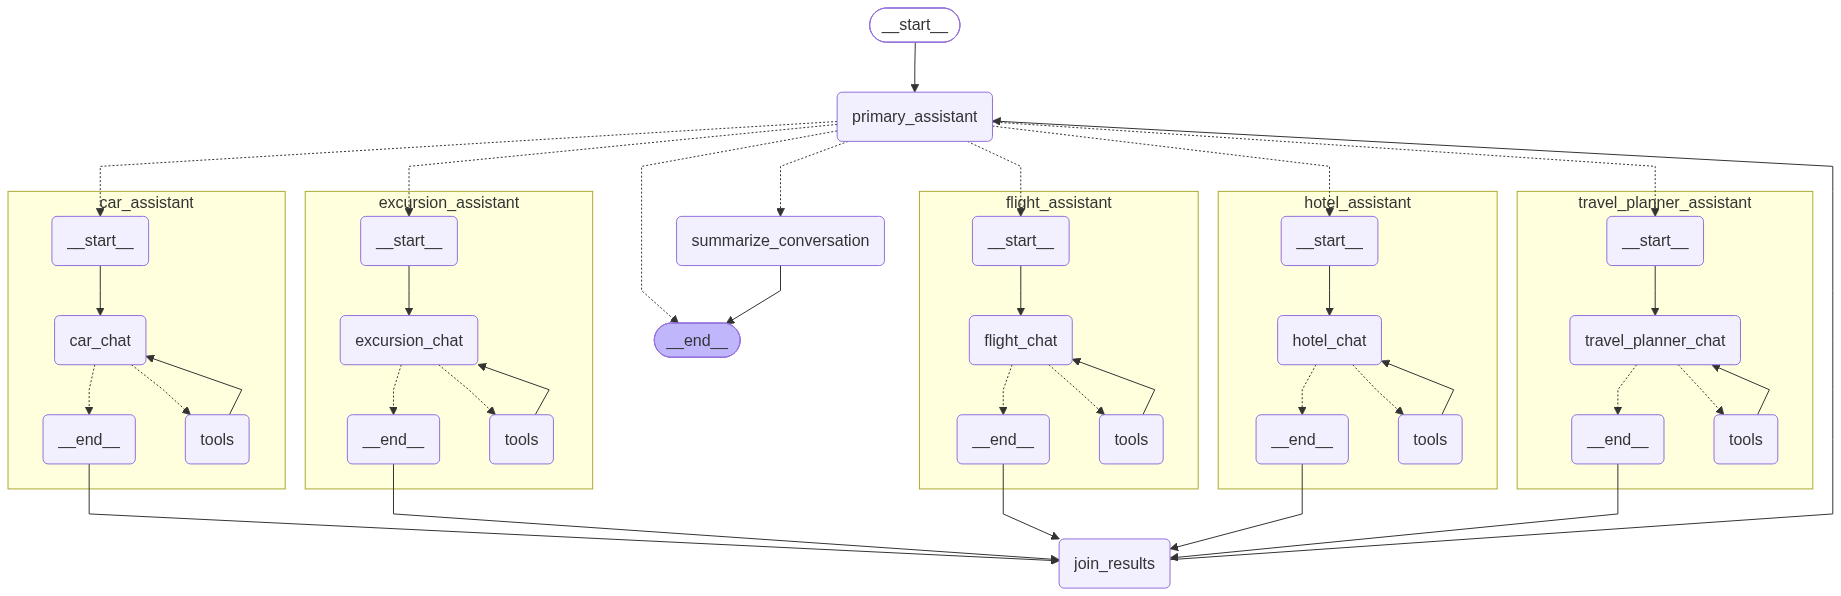

In [3]:

from IPython.display import Image, display

try:
    display(Image(graph.get_graph(xray=True).draw_mermaid_png()))
except Exception:
    pass

In [2]:
_printed = set()

def _print_event(event: dict, _printed: set, max_length=5000):
    messages = event.get("messages")
    if not messages:
        return

    if not isinstance(messages, list):
        messages = [messages]

    for message in messages:
        message_id = getattr(message, "id", None)
        if message_id in _printed:
            continue

        msg_repr = message.pretty_repr(html=True)
        if len(msg_repr) > max_length:
            msg_repr = msg_repr[:max_length] + " ... (truncated)"
        print(msg_repr)
        if message_id:
            _printed.add(message_id)

In [3]:
tutorial_questions = [
    "Tìm khách sạn ở Hà Nội, check-in 20/8/2026, check-out 23/8/2026.",
    "Cho tôi xem review của khách sạn thứ 3",
    # " Tìm vé một chiều Sài Gòn đi Hà Nội ngày 21/8/2026.",
    " Tôi muốn kiếm tour ở chỗ đó ngày 23/8/2026.",
]

_printed = set()

for question in tutorial_questions:
    events = graph.astream(
        {
            "messages": ("user", question),
            "user_id": user_id,
            "thread_id": thread_id,
        },
        config,
        stream_mode="values",
    )
    async for event in events:
        _print_event(event, _printed)

================================ Human Message =================================

Tìm khách sạn ở Hà Nội, check-in 20/8/2026, check-out 23/8/2026.
================================== Ai Message ==================================
Tool Calls:
  ToHotelAssistant (a1a37923-a884-444c-bd11-47a4fb8da65f)
 Call ID: a1a37923-a884-444c-bd11-47a4fb8da65f
  Args:
    request: Tìm khách sạn ở Hà Nội, check-in 20/8/2026, check-out 23/8/2026.
================================= Tool Message =================================

Dưới đây là một số khách sạn ở Hà Nội có phòng trống từ ngày 20/08/2026 đến ngày 23/08/2026:

*   **La Casa Di Dicembre 118 Khương Đình** (ID: 16937777) - Giá: 337500 VND - Xếp hạng: 0
    ![La Casa Di Dicembre 118 Khương Đình](https://cf.bstatic.com/xdata/images/hotel/square500/898635879.jpg?k=a66d6d2b28c67da4ed1442197f74f3a2a4a49db5cd46f4a4670eb0edfe0cea0a&o=)
*   **Solaria d'Oriente Hotel** (ID: 16527993) - Giá: 2035500 VND - Xếp hạng: 9.4
    ![Solaria d'Oriente Hotel](https://c

In [3]:
import json
from pprint import pprint
from services.reference_resolver import resolve_item_reference

snapshot = await graph.aget_state(config)
values = snapshot.values
messages = values.get("messages") or []

print("=== META ===")
print("next:", snapshot.next)
print("user_id:", values.get("user_id"))
print("thread_id:", values.get("thread_id") or config["configurable"]["thread_id"])
print("dialog_state:", values.get("dialog_state"))
print("active_assistant:", values.get("active_assistant"))

print("\n=== SHORT-TERM MEMORY (trong checkpoint) ===")
print("summary:", values.get("summary"))
print("active_request_id:", values.get("active_request_id"))
print("latest_request_by_domain:")
pprint(values.get("latest_request_by_domain"))
print("requests:")
pprint(values.get("requests"))
print("request_results:")
pprint(values.get("request_results"))
print("visible_results:")
pprint(values.get("visible_results"))
print("selected_items:")
pprint(values.get("selected_items"))
print("flight_token_map keys:", list((values.get("flight_token_map") or {}).keys())[:10])

print("\n=== MESSAGES WINDOW ===")
print("message_count:", len(messages))
for i, msg in enumerate(messages):
    role = getattr(msg, "type", msg.__class__.__name__)
    content = getattr(msg, "content", "")
    preview = str(content).replace("\n", " ")[:160]
    tool_calls = getattr(msg, "tool_calls", None) or []
    extra = f" | tool_calls={[tc.get('name') for tc in tool_calls]}" if tool_calls else ""
    print(f"[{i}] {role}: {preview}{extra}")

print("\n=== RESOLVE 'thứ 2' BẰNG CODE ===")
resolved = resolve_item_reference(values, domain="hotel", position=2)
print(resolved)

# Nếu có search_id, tải payload tạm từ Result Store (không nằm trong State)
visible = values.get("visible_results") or {}
req_id = (values.get("latest_request_by_domain") or {}).get("hotel")
if req_id and req_id in visible:
    ref = visible[req_id]
    items = await repo.load_items(
        search_id=ref["search_id"],
        item_ids=ref.get("displayed_item_ids") or [],
        user_id=user_id,
        thread_id=thread_id,
    )
    print("\n=== RESULT STORE PAYLOAD (ngoài State) ===")
    print(json.dumps(items, ensure_ascii=False, indent=2)[:2000])


=== META ===
next: ()
user_id: 31082004
thread_id: 123
dialog_state: []
active_assistant: None

=== SHORT-TERM MEMORY (trong checkpoint) ===
summary: 
active_request_id: req_tour_76995082
latest_request_by_domain:
{'hotel': 'req_hotel_8cb37a78', 'tour': 'req_tour_76995082'}
requests:
{'req_hotel_8cb37a78': {'domain': 'hotel', 'status': 'completed'},
 'req_tour_76995082': {'domain': 'tour', 'status': 'completed'}}
request_results:
{'req_hotel_8cb37a78': {'domain': 'hotel',
                        'search_id': 'f9fee02d-31f6-4e7c-97d2-668f79224f14',
                        'total_results': 10},
 'req_tour_76995082': {'domain': 'tour',
                       'search_id': 'b9c212d3-0a51-4ef7-9347-19032ce5587b',
                       'total_results': 10}}
visible_results:
{'req_hotel_8cb37a78': {'displayed_item_ids': ['16937777',
                                               '16527993',
                                               '9777765',
                                             

ResultStoreExpiredError: Search f9fee02d-31f6-4e7c-97d2-668f79224f14 expired at 2026-07-29T09:33:36.525258+07:00

In [3]:
tutorial_questions = [
    " Tìm khách sạn Đà Nẵng check in ngày 21/8/2026, check out ngày 22/8/2026.",
    " Tôi muốn kiếm tour ở Đà Nẵng ngày 22/8/2026.",
    " Cho tôi xem review của tour thứ 2",
]
user_id = "31082004"
thread_id = "444"
_printed = set()
config = with_trace_config(
    {"configurable": {"thread_id": thread_id, "user_id": user_id}},
    run_name="notebook_primary",
    tags=["notebook", "primary"],
    metadata={"thread_id": thread_id, "user_id": user_id},
)
for question in tutorial_questions:
    events = graph.astream(
        {"messages": ("user", question), "user_id": user_id, "thread_id": thread_id},
        config,
        stream_mode="values",
    )
    async for event in events:
        _print_event(event, _printed)
    snap = await graph.aget_state(config)
    msgs = snap.values.get("messages") or []
    old = select_messages_to_summarize(msgs)  # default keep_count=2
    print(
        f"\n>> {question.strip()!r}\n"
        f"   msgs={len(msgs)}  summary_len={len(snap.values.get('summary') or '')}\n"
        f"   would_remove={len(old)}  route={should_summarize(snap.values)}\n"
    )

================================ Human Message =================================

 Tìm khách sạn Đà Nẵng check in ngày 21/8/2026, check out ngày 22/8/2026.
================================== Ai Message ==================================
Tool Calls:
  ToHotelAssistant (fec1da4b-787d-4d61-a193-c9c4329eeef7)
 Call ID: fec1da4b-787d-4d61-a193-c9c4329eeef7
  Args:
    request: Tìm khách sạn Đà Nẵng check in ngày 21/8/2026, check out ngày 22/8/2026.
================================= Tool Message =================================

Đây là một số khách sạn ở Đà Nẵng có phòng trống từ ngày 21/08/2026 đến ngày 22/08/2026:

*   **JBay Coastal Residence** (ID: 16960240) - Giá: 1.020.000 VND - Đánh giá: 9.3 ![JBay Coastal Residence](https://cf.bstatic.com/xdata/images/hotel/square500/901168807.jpg?k=182924a2bafd304e67798f995dc8c68ef71f439c084829b1fc8f64c638b9a4bb&o=)
*   **Mercure Danang French Village Bana Hills** (ID: 1395573) - Giá: 2.880.000 VND - Đánh giá: 7.9 ![Mercure Danang French Village Ba

In [4]:
import json
from pprint import pprint
from services.reference_resolver import resolve_item_reference

snapshot = await graph.aget_state(config)
values = snapshot.values
messages = values.get("messages") or []

print("=== META ===")
print("next:", snapshot.next)
print("user_id:", values.get("user_id"))
print("thread_id:", values.get("thread_id") or config["configurable"]["thread_id"])
print("dialog_state:", values.get("dialog_state"))
print("active_assistant:", values.get("active_assistant"))

print("\n=== SHORT-TERM MEMORY (trong checkpoint) ===")
print("summary:", values.get("summary"))
print("active_request_id:", values.get("active_request_id"))
print("latest_request_by_domain:")
pprint(values.get("latest_request_by_domain"))
print("requests:")
pprint(values.get("requests"))
print("request_results:")
pprint(values.get("request_results"))
print("visible_results:")
pprint(values.get("visible_results"))
print("selected_items:")
pprint(values.get("selected_items"))
print("flight_token_map keys:", list((values.get("flight_token_map") or {}).keys())[:10])

print("\n=== MESSAGES WINDOW ===")
print("message_count:", len(messages))
for i, msg in enumerate(messages):
    role = getattr(msg, "type", msg.__class__.__name__)
    content = getattr(msg, "content", "")
    preview = str(content).replace("\n", " ")[:160]
    tool_calls = getattr(msg, "tool_calls", None) or []
    extra = f" | tool_calls={[tc.get('name') for tc in tool_calls]}" if tool_calls else ""
    print(f"[{i}] {role}: {preview}{extra}")

print("\n=== RESOLVE 'thứ 2' BẰNG CODE ===")
resolved = resolve_item_reference(values, domain="hotel", position=2)
print(resolved)

# Nếu có search_id, tải payload tạm từ Result Store (không nằm trong State)
visible = values.get("visible_results") or {}
req_id = (values.get("latest_request_by_domain") or {}).get("hotel")
if req_id and req_id in visible:
    ref = visible[req_id]
    items = await repo.load_items(
        search_id=ref["search_id"],
        item_ids=ref.get("displayed_item_ids") or [],
        user_id=user_id,
        thread_id=thread_id,
    )
    print("\n=== RESULT STORE PAYLOAD (ngoài State) ===")
    print(json.dumps(items, ensure_ascii=False, indent=2)[:2000])


=== META ===
next: ()
user_id: 31082004
thread_id: 444
dialog_state: []
active_assistant: None

=== SHORT-TERM MEMORY (trong checkpoint) ===
summary: Người dùng đã yêu cầu tìm khách sạn tại Đà Nẵng với ngày nhận phòng 21/08/2026 và trả phòng 22/08/2026. Trợ lý đã tìm thấy 5 khách sạn có phòng trống cho các ngày này.
active_request_id: req_tour_c3c45cac
latest_request_by_domain:
{'hotel': 'req_hotel_6d0d5604', 'tour': 'req_tour_c3c45cac'}
requests:
{'req_hotel_6d0d5604': {'domain': 'hotel', 'status': 'completed'},
 'req_tour_c3c45cac': {'domain': 'tour', 'status': 'completed'}}
request_results:
{'req_hotel_6d0d5604': {'domain': 'hotel',
                        'search_id': 'f82d4377-723f-47c5-bee1-529e15b1706c',
                        'total_results': 10},
 'req_tour_c3c45cac': {'domain': 'tour',
                       'search_id': '9c7b79af-e42f-4fd4-8d6d-1203e19fab04',
                       'total_results': 10}}
visible_results:
{'req_hotel_6d0d5604': {'displayed_item_ids': ['169602

In [3]:
tutorial_questions = [
    "Tôi muốn kiếm chuyen bay từ tp hcm đến Phú Yên ngày 21/8/2026.",
    "Tôi muốn book chuyến thứ 2."
]
user_id = "31082004"
thread_id = "333445556"
_printed = set()
config = with_trace_config(
    {"configurable": {"thread_id": thread_id, "user_id": user_id}},
    run_name="notebook_primary",
    tags=["notebook", "primary"],
    metadata={"thread_id": thread_id, "user_id": user_id},
)
for question in tutorial_questions:
    events = graph.astream(
        {"messages": ("user", question), "user_id": user_id, "thread_id": thread_id},
        config,
        stream_mode="values",
    )
    async for event in events:
        _print_event(event, _printed)
    snap = await graph.aget_state(config)
    msgs = snap.values.get("messages") or []
    old = select_messages_to_summarize(msgs)  # default keep_count=2
    print(
        f"\n>> {question.strip()!r}\n"
        f"   msgs={len(msgs)}  summary_len={len(snap.values.get('summary') or '')}\n"
        f"   would_remove={len(old)}  route={should_summarize(snap.values)}\n"
    )

================================ Human Message =================================

Tôi muốn kiếm chuyen bay từ tp hcm đến Phú Yên ngày 21/8/2026.
================================== Ai Message ==================================
Tool Calls:
  ToFlightAssistant (82715ad9-612d-4400-a647-1b13d271d943)
 Call ID: 82715ad9-612d-4400-a647-1b13d271d943
  Args:
    request: tìm chuyến bay từ tp hcm đến Phú Yên ngày 21/8/2026
================================= Tool Message =================================

[{'type': 'text', 'text': 'Đây là các chuyến bay một chiều từ Hồ Chí Minh đến Tuy Hòa vào ngày 21/08/2026:\n\n*   **Offer_ID:** FL-0B5C6A\n    *   **Giá:** 1.528.181 VND\n    *   **Hãng hàng không:** Vietnam Airlines (VN)\n    *   **Điểm dừng:** 0\n    *   **Thời gian bay:** 1 giờ 30 phút\n    *   **Khởi hành:** 16:50 ngày 21/08/2026 từ SGN (Cảng hàng không quốc tế Tân Sơn Nhất)\n    *   **Đến:** 18:20 ngày 21/08/2026 tại TBB (Cảng Hàng không Tuy Hòa)\n    *   **Số hiệu chuyến bay:** 8440\n    * 